# Évaluation des modèles

Pour chaque modèle : classification_report, matrice de confusion,
courbes **ROC** et **PR**. Sur un jeu déséquilibré, la **PR-AUC**
et le **rappel** sont les métriques prioritaires.


In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

sys.path.insert(0, os.path.abspath('../src'))
from preprocessing import load_data, scale_features, split_data
from predict import FraudPredictor

sns.set_theme(style='whitegrid')
MODELES = ['logistic_regression', 'random_forest', 'xgboost']
SCALER_PATH = '../models/scaler.joblib'


## 1. Préparation du jeu de test


In [2]:
df = load_data('../data/creditcard.csv')
df_scaled, scaler = scale_features(df, fit=True, save_path=SCALER_PATH)
X_train, X_test, y_train, y_test = split_data(df_scaled)

print(f'Jeu de test : {X_test.shape[0]} transactions, '
      f'{y_test.sum()} fraudes.')


Données chargées : 284807 transactions, 31 colonnes.
Scaler sauvegardé dans : ../models/scaler.joblib
Split : 227845 en entraînement, 56962 en test.
Jeu de test : 56962 transactions, 98 fraudes.


## 2. Fonction d'évaluation commune



===== logistic_regression =====
              precision    recall  f1-score   support

     Normale       1.00      0.98      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC : 0.9721  |  PR-AUC : 0.7189



===== random_forest =====
              precision    recall  f1-score   support

     Normale       1.00      1.00      1.00     56864
      Fraude       0.71      0.85      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9828  |  PR-AUC : 0.8500



===== xgboost =====
              precision    recall  f1-score   support

     Normale       1.00      1.00      1.00     56864
      Fraude       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9673  |  PR-AUC : 0.8852


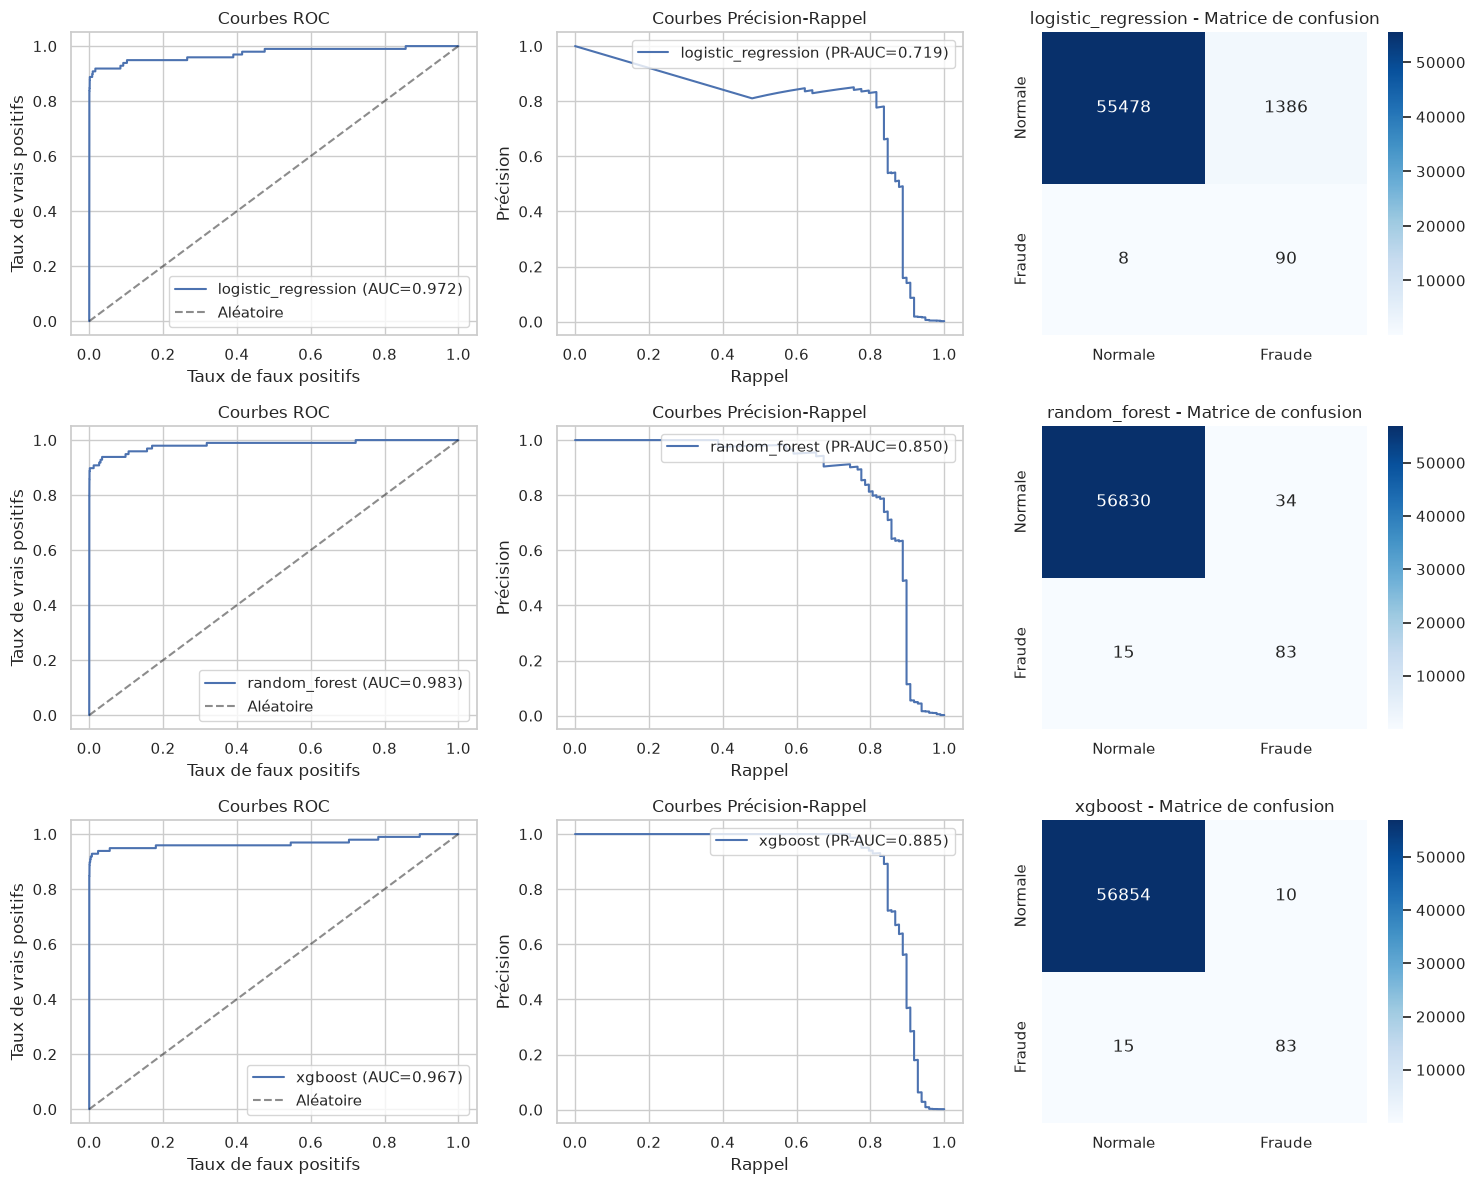

In [3]:
def evaluer_modele(nom, ax_roc, ax_pr, ax_cm):
    """Évalue un modèle : métriques + courbes + matrice de confusion."""
    predictor = FraudPredictor(f'../models/{nom}.joblib', scaler_path=SCALER_PATH)
    proba = predictor.model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    print(f'\n===== {nom} =====')
    print(classification_report(y_test, y_pred, target_names=['Normale', 'Fraude']))

    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')

    # Matrice de confusion (en proportions pour voir la classe minoritaire)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Normale', 'Fraude'],
                yticklabels=['Normale', 'Fraude'])
    ax_cm.set_title(f'{nom} - Matrice de confusion')

    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, label=f'{nom} (AUC={roc_auc:.3f})')
    ax_roc.set_xlabel('Taux de faux positifs')
    ax_roc.set_ylabel('Taux de vrais positifs')
    ax_roc.set_title('Courbes ROC')

    # Courbe Précision-Rappel
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax_pr.plot(recall, precision, label=f'{nom} (PR-AUC={pr_auc:.3f})')
    ax_pr.set_xlabel('Rappel')
    ax_pr.set_ylabel('Précision')
    ax_pr.set_title('Courbes Précision-Rappel')

    return {'modèle': nom, 'ROC-AUC': roc_auc, 'PR-AUC': pr_auc}


resultats = []
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, nom in enumerate(MODELES):
    ax_roc, ax_pr, ax_cm = axes[i]
    res = evaluer_modele(nom, ax_roc, ax_pr, ax_cm)
    resultats.append(res)

# Ligne de référence des courbes
for ax in axes[:, 0]:
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aléatoire')
for ax in axes[:, 0]:
    ax.legend(loc='lower right')
for ax in axes[:, 1]:
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 3. Tableau comparatif final


In [4]:
comparaison = pd.DataFrame(resultats).set_index('modèle')
comparaison = comparaison.sort_values('PR-AUC', ascending=False)
comparaison.style.format({k: '{:.4f}' for k in comparaison.columns}).background_gradient(cmap='Blues')


,ROC-AUC,PR-AUC
modèle,,
xgboost,0.9673,0.8852
random_forest,0.9828,0.8500
logistic_regression,0.9721,0.7189


## Conclusion

Le **best model** est celui avec la meilleure PR-AUC et le meilleur
rapport rappel/précision. Reportez les valeurs dans le tableau
**Résultats** du README.md. Le modèle retenu est ensuite utilisé par
`app/app.py` et `src/predict.py`.
